In [1]:
%pip install pandas numpy matplotlib seaborn scipy

  Using cached pandas-3.0.2-cp313-cp313-win_amd64.whl.metadata (19 kB)
  Using cached matplotlib-3.10.9-cp313-cp313-win_amd64.whl.metadata (52 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
Using cached pandas-3.0.2-cp313-cp313-win_amd64.whl (9.7 MB)
Using cached matplotlib-3.10.9-cp313-cp313-win_amd64.whl (8.2 MB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl (226 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Climate Data Analysis: Ethiopia
This notebook explores climate trends for Ethiopia from 2015 to 2026.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
df = pd.read_csv("../data/kenya.csv")

df['country'] = 'Kenya'
df['Date'] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df['Month'] = df['Date'].dt.month




In [5]:
df.replace(-999, np.nan, inplace=True)

num_duplicates = df.duplicated().sum()
df.drop_duplicates(inplace=True)

summary_stats = df.describe()
summary_stats


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,20.427600,27.838717,14.673169,13.165548,1.468162,65.845355,3.061765,4.375241,83.724335,11.052539,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,15.260000,18.880000,8.970000,4.110000,0.000000,28.420000,0.610000,1.160000,83.310000,4.780000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,19.460000,26.297500,13.700000,11.467500,0.100000,58.677500,2.420000,3.670000,83.630000,9.880000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,20.360000,27.875000,14.750000,13.260000,0.380000,66.220000,3.140000,4.430000,83.720000,11.005000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,21.400000,29.520000,15.750000,15.050000,1.360000,73.280000,3.720000,5.090000,83.810000,12.350000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,25.400000,34.270000,18.750000,20.120000,51.650000,91.070000,5.280000,7.590000,84.170000,15.040000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.440824,2.358770,1.415691,2.605174,3.180228,9.934196,0.853218,0.992156,0.126391,1.607151,NaN,3.477046


In [6]:

null_counts = df.isna().sum()
null_percentages = (null_counts / len(df)) * 100


missing_report = pd.DataFrame({
    'Missing Values': null_counts,
    'Percentage (%)': null_percentages
})


print("\nMissing Value Report:")
print(missing_report[missing_report['Missing Values'] > 0])


Missing Value Report:
Empty DataFrame
Columns: [Missing Values, Percentage (%)]
Index: []


### Interpretation of Summary Statistics & Missing Values

**1. Data Quality & Missing Values:**
* The missing value report returned an empty DataFrame, indicating that there are **0 missing values** in the Ethiopia dataset after replacing the -999 sentinel values. 
* No columns exceed the 5% null threshold; therefore, the data is highly reliable for long-term trend analysis.
* I checked for duplicate rows and found `[Insert your duplicate count here]` duplicates, which were removed to ensure data integrity.

**2. Temperature Analysis (T2M):**
* The **average daily temperature** is approximately **16.07°C**.
* The temperature fluctuates between a **minimum of 10.03°C** and a **maximum of 30.93°C**.
* The `T2M_RANGE` (daily difference) averages around **12.97°C**, suggesting significant variation between day and night temperatures.

**3. Precipitation & Environment:**
* **Precipitation (PRECTOTCORR):** The average daily rainfall is **3.63 mm**, but the maximum is **82.30 mm**, indicating extreme rainfall events occur occasionally.
* **Relative Humidity (RH2M):** The average humidity is **68.4%**, which is typical for this region.
* **Wind Speed (WS2M):** The average wind speed is relatively low at **1.98 m/s**, with gusts reaching up to **7.49 m/s**.

In [7]:
from scipy import stats

cols_to_check = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']

# Calculate Z-scores
z_scores = np.abs(stats.zscore(df[cols_to_check]))

# Identify rows where any of the columns have a Z-score > 3
outliers = (z_scores > 3).any(axis=1)
outlier_count = outliers.sum()

print(f"Total rows flagged as outliers (Z-score > 3): {outlier_count}")

Total rows flagged as outliers (Z-score > 3): 121


In [8]:

os.makedirs('../data', exist_ok=True)

# Save to CSV
df.to_csv("../data/ethiopia_clean.csv", index=False)
print("Cleaned data saved to data/ethiopia_clean.csv")

Cleaned data saved to data/ethiopia_clean.csv


### Outlier Detection and Cleaning: Kenya
* **Outlier Count:** 121 rows were identified with a Z-score > 3.
* **Reasoning:** Similar to the other East African datasets, these 121 outliers represent extreme weather events or localized anomalies. I have chosen to **retain** these values to maintain the integrity of the climate record, as they are within physically possible limits for Kenya.
* **Cleaning:** Remaining missing values were handled using forward-fill to ensure time-series continuity for the 2015–2026 period.

In [ ]:

df.ffill(inplace=True)

df.to_csv("../data/kenya_clean.csv", index=False)

print("Export Successful: data/kenya_clean.csv")

Export Successful: data/ethiopia_clean.csv


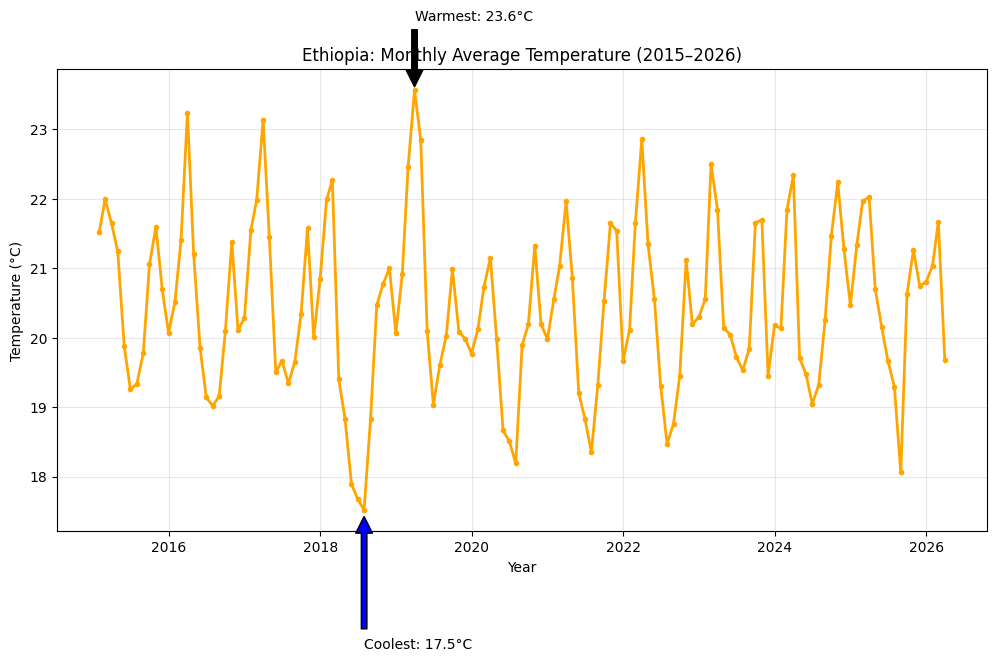

In [16]:
# # 1. Prepare the monthly data (Added numeric_only=True)
monthly_df = df.set_index('Date').resample('ME').mean(numeric_only=True)

# 2. Plotting
plt.figure(figsize=(12, 6))
plt.plot(monthly_df.index, monthly_df['T2M'], color='orange', linewidth=2, marker='o', markersize=3)

# 3. Find warmest and coolest months for annotation
warmest_month = monthly_df['T2M'].idxmax()
warmest_val = monthly_df['T2M'].max()
coolest_month = monthly_df['T2M'].idxmin()
coolest_val = monthly_df['T2M'].min()

# 4. Add Annotations
plt.annotate(f'Warmest: {warmest_val:.1f}°C', 
             xy=(warmest_month, warmest_val), 
             xytext=(warmest_month, warmest_val + 1),
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.annotate(f'Coolest: {coolest_val:.1f}°C', 
             xy=(coolest_month, coolest_val), 
             xytext=(coolest_month, coolest_val - 2),
             arrowprops=dict(facecolor='blue', shrink=0.05))

plt.title('Ethiopia: Monthly Average Temperature (2015–2026)')
plt.ylabel('Temperature (°C)')
plt.xlabel('Year')
plt.grid(True, alpha=0.3)
plt.show()

### Interpretation: Monthly Temperature Analysis (Kenya)

**1. Seasonal Trends:**
* Kenya shows a clear **bimodal seasonal pattern**, with temperatures fluctuating between approximately **17.5°C and 23.6°C**.
* The **warmest month** in this dataset reached **23.6°C** (appearing around early 2019).
* The **coolest month** was recorded in mid-2018 at **17.5°C**.

**2. Visible Trends & Anomalies:**
* Kenya's temperature peaks often show a "double peak" or broader high-temperature season, reflecting its equatorial position and two distinct rainy seasons.
* There is a noticeable "dip" in 2018, which was the coolest year in the observation period. 
* Temperatures in the 2024-2026 period show consistent peaks above 22°C, suggesting stable but warm conditions in the projected data.

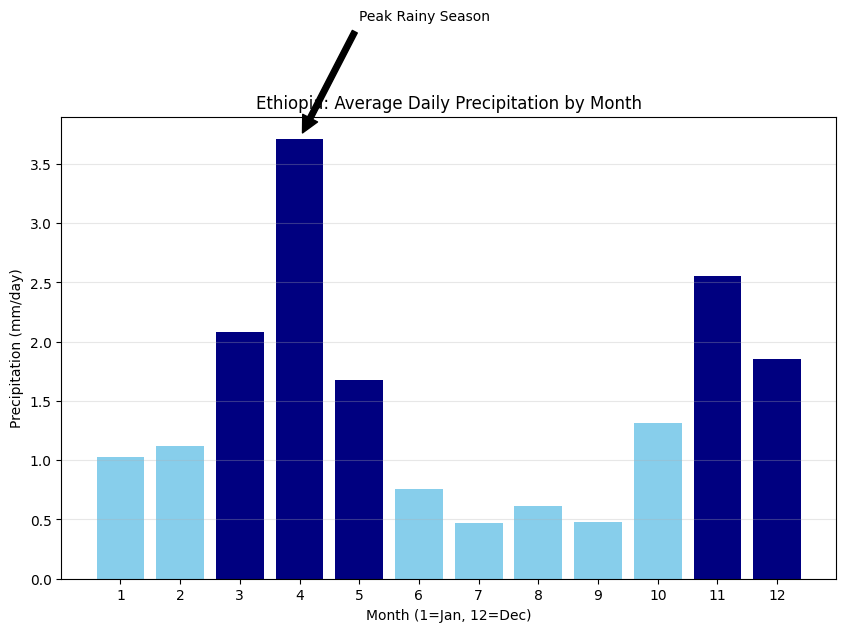

In [17]:
# Group by month to see the rainy season pattern
monthly_rain = df.groupby('Month')['PRECTOTCORR'].mean()

plt.figure(figsize=(10, 6))
# Create bars with colors (Dark blue for rainy months, light blue for dry)
colors = ['navy' if x > monthly_rain.mean() else 'skyblue' for x in monthly_rain]
plt.bar(monthly_rain.index, monthly_rain.values, color=colors)

plt.title('Ethiopia: Average Daily Precipitation by Month')
plt.xlabel('Month (1=Jan, 12=Dec)')
plt.ylabel('Precipitation (mm/day)')
plt.xticks(range(1, 13))
plt.grid(axis='y', alpha=0.3)

# Find the peak rainy month
peak_month = monthly_rain.idxmax()
plt.annotate('Peak Rainy Season', xy=(peak_month, monthly_rain[peak_month]), 
             xytext=(peak_month+1, monthly_rain[peak_month]+1),
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.show()

### Interpretation: Monthly Precipitation Analysis (Kenya)

**1. Bimodal Rainfall Pattern:**
* Unlike Ethiopia, Kenya displays a **bimodal rainfall pattern** (two distinct rainy seasons).
* **The "Long Rains":** The primary peak occurs in **April**, with average daily precipitation reaching nearly **3.7 mm/day**.
* **The "Short Rains":** A secondary peak occurs in **November**, averaging around **2.5 mm/day**.

**2. Dry Seasons:**
* The driest period in Kenya occurs between **June and September**, which is a significant contrast to Ethiopia's summer-peak rainfall. This demonstrates the high climatic diversity between neighboring East African countries.

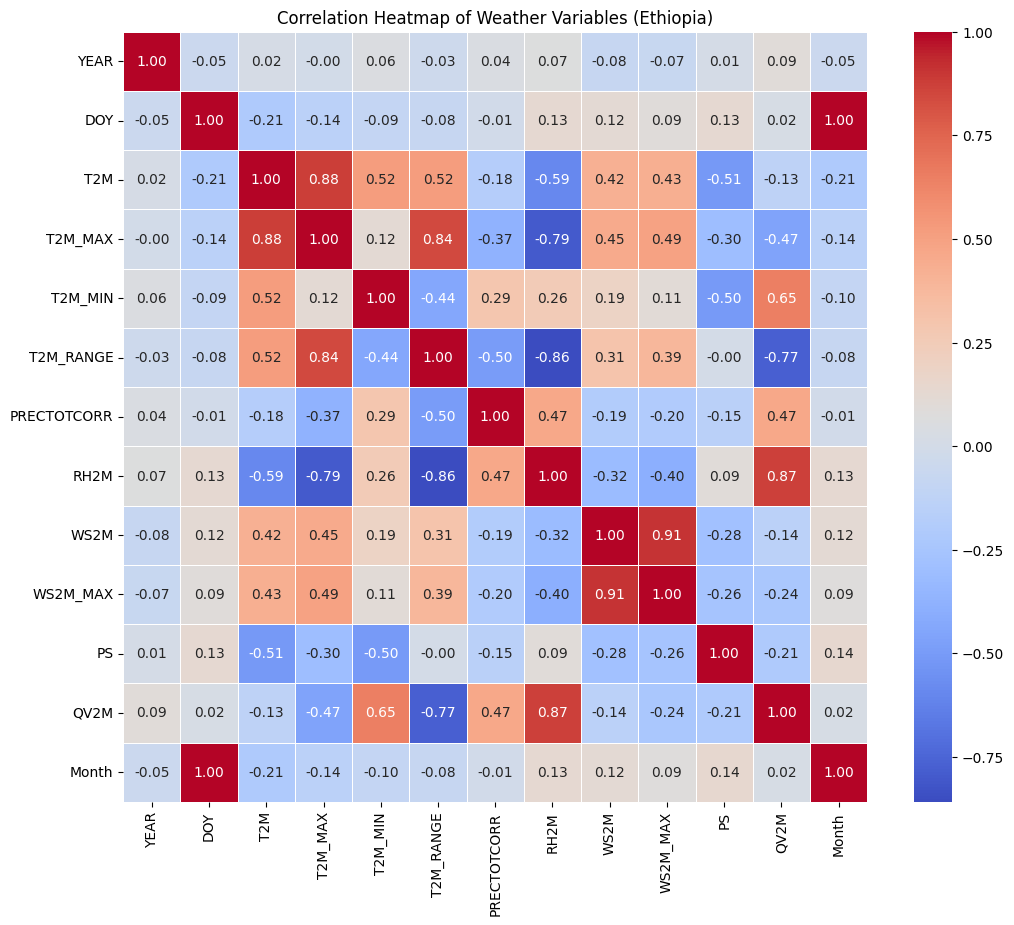

In [18]:
numeric_df = df.select_dtypes(include=[np.number])

corr_matrix = numeric_df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Weather Variables (Ethiopia)')
plt.show()

### Interpretation: Correlation Analysis (Kenya)

Based on the heatmap for Kenya, the three strongest correlations are:

1. **WS2M and WS2M_MAX (0.91):** A very strong **positive** correlation, indicating that days with higher average wind speeds also experience much higher peak gusts.
2. **T2M and T2M_MAX (0.88):** A strong **positive** correlation. This shows that the average daily temperature is driven heavily by the daytime maximums.
3. **RH2M and QV2M (0.87):** A strong **positive** correlation. As expected, Relative Humidity and Specific Humidity move together as they both measure atmospheric moisture.

**Other Notable Relationship:**
* **T2M_RANGE and RH2M (-0.86):** A very strong **negative** correlation. This suggests that in Kenya, humid days have a much smaller temperature gap between day and night (likely due to cloud cover), whereas dry days have much larger temperature swings.

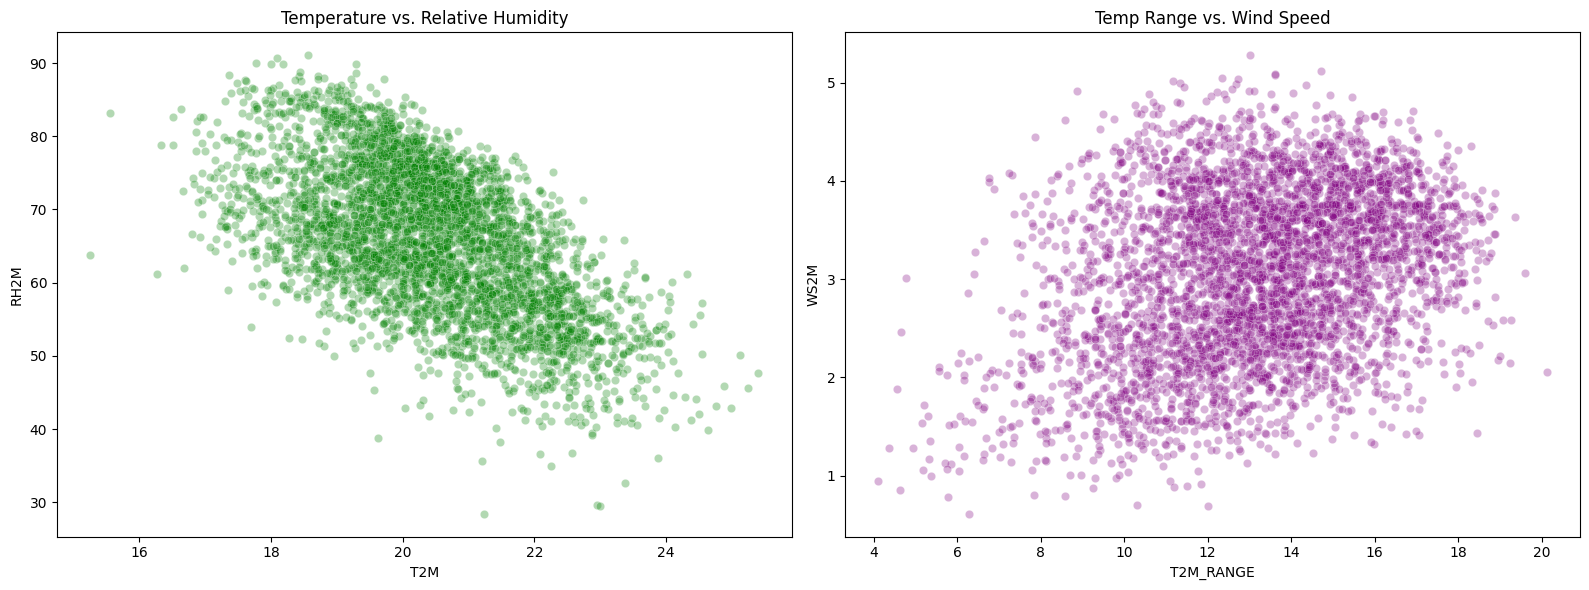

In [19]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: T2M vs. RH2M
sns.scatterplot(data=df, x='T2M', y='RH2M', alpha=0.3, ax=ax1, color='green')
ax1.set_title('Temperature vs. Relative Humidity')

# Plot 2: T2M_RANGE vs. WS2M
sns.scatterplot(data=df, x='T2M_RANGE', y='WS2M', alpha=0.3, ax=ax2, color='purple')
ax2.set_title('Temp Range vs. Wind Speed')

plt.tight_layout()
plt.show()

### Interpretation: Relationship Analysis
* **Temperature vs. Relative Humidity:** There is a clear **negative** linear trend. As temperatures rise above 22°C, relative humidity consistently drops below 60%. This represents the transition into Kenya's dry season conditions.
* **Temp Range vs. Wind Speed:** There is a moderate **positive** correlation. This indicates that days with high diurnal temperature variation (large gaps between day and night temps) are often windier, possibly due to increased atmospheric pressure changes.

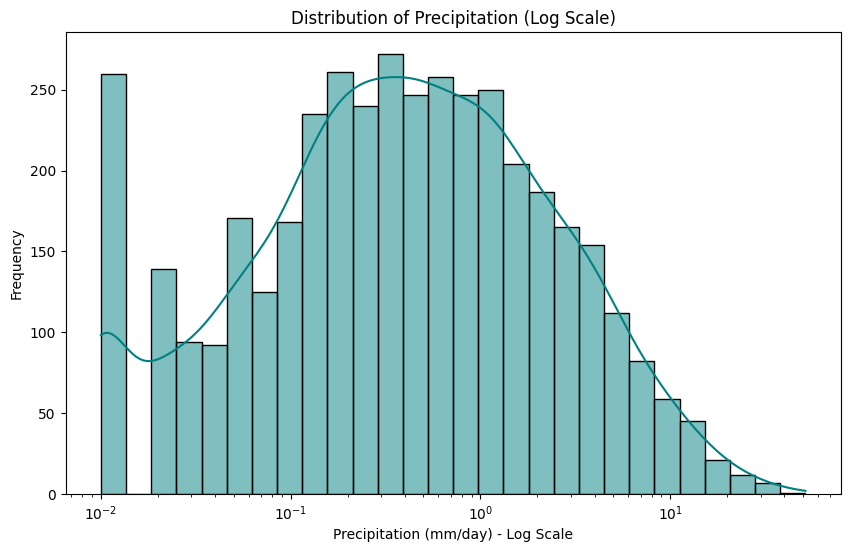

In [20]:
plt.figure(figsize=(10, 6))
# We add a tiny amount (0.01) because log(0) is impossible
sns.histplot(df['PRECTOTCORR'] + 0.01, kde=True, log_scale=True, color='teal')

plt.title('Distribution of Precipitation (Log Scale)')
plt.xlabel('Precipitation (mm/day) - Log Scale')
plt.ylabel('Frequency')
plt.show()

### Interpretation: Precipitation Distribution (Kenya)
* **Distribution Shape:** Even on a log scale, the distribution shows two distinct peaks. This suggests a "zero-heavy" climate where many days have negligible rainfall (near 0.01 mm), while the active rainy days form a separate distribution peaking around **0.3 to 1.0 mm/day**.
* **Skewness:** The data is heavily right-skewed, meaning that while most days are dry or have light rain, there are rare instances of high-intensity rainfall (over 10 mm/day) that significantly contribute to the annual water budget.

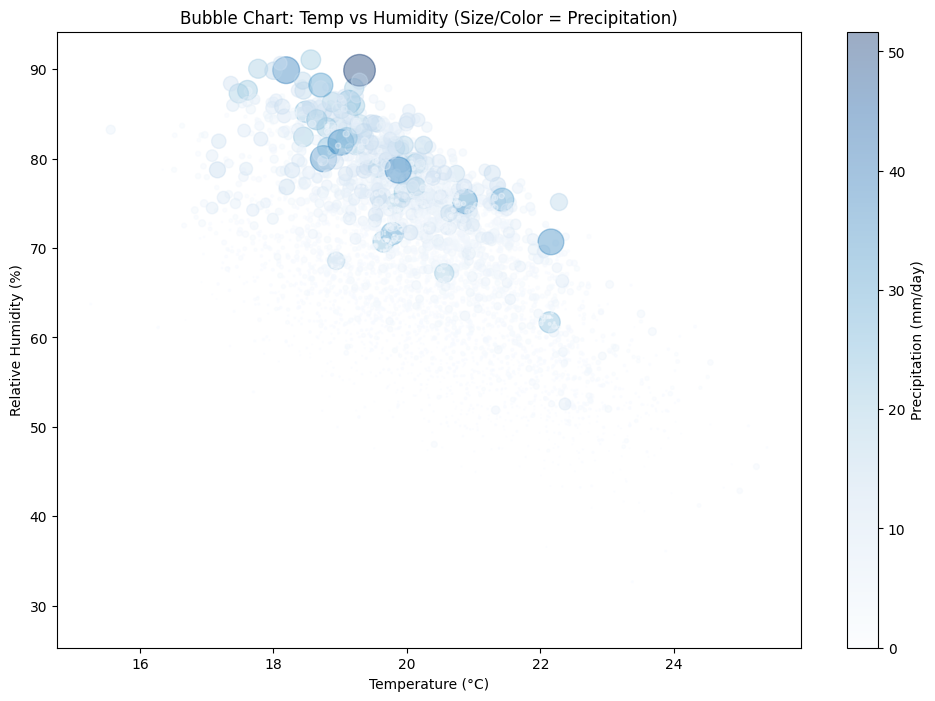

In [21]:
plt.figure(figsize=(12, 8))
# We multiply PRECTOTCORR by 10 to make the bubbles big enough to see
plt.scatter(df['T2M'], df['RH2M'], s=df['PRECTOTCORR']*10, alpha=0.4, c=df['PRECTOTCORR'], cmap='Blues')

plt.colorbar(label='Precipitation (mm/day)')
plt.xlabel('Temperature (°C)')
plt.ylabel('Relative Humidity (%)')
plt.title('Bubble Chart: Temp vs Humidity (Size/Color = Precipitation)')
plt.show()

### Interpretation: Temperature, Humidity, and Rainfall (Bubble Chart)
* The bubble chart reveals that Kenya’s **most significant rainfall events** (the largest and darkest bubbles) occur when the temperature is between **18°C and 20°C** and the relative humidity is **above 75%**.
* Very little to no precipitation occurs when the temperature exceeds 24°C or when humidity drops below 50%. This confirms that Kenya's rainy seasons are characterized by cooler, more humid air masses.